# 13 — Historical Upsets vs Heatmap & a Fight-Level Model

**Goal:** Study **underdog wins** (upsets) and ask whether (a) the **style win-rate heatmap** (notebook 11, k=5 GMM) and (b) a **supervised classifier** tended to point the same way as *who actually won*.  
**Limitation (Elo favorite):** This notebook defines “favorite” with **pre-fight Elo** by walking fights in **sorted (`Event_Id`, `Fight_Id`)** order (not guaranteed strictly chronological). Interpret Elo-upsets as a **structural underdog metric**. For **Vegas** closing lines and a comparison to these signals on the same event split, run **14 (odds cleaning)** then **15** after placing the Kaggle odds CSV under `data/raw/kaggle_odds/`.

**Inputs:** `ufc_fight_stats_cleaned.csv`, `ufc_gmm_comparison.csv`  
**Takeaway:** Report heatmap “directional accuracy” on upsets vs non-upsets and compare to an RF trained on **static** Z-score deltas with a simple **time split by event**.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss

K_ELO = 32.0
ELO_INIT = 1500.0

fights = pd.read_csv('../data/processed/ufc_fight_stats_cleaned.csv')
styles = pd.read_csv('../data/processed/ufc_gmm_comparison.csv')
cluster_col = 'Cluster_k5'

style_map = styles[['Fighter', cluster_col]].set_index('Fighter')
z_cols = ['Sig_Str_PM_Z', 'Takedown_Att_PM_Z', 'Sub_Att_PM_Z', 'Control_Ratio_Z']
z_map = styles[['Fighter'] + z_cols].set_index('Fighter')

df = fights.merge(style_map, left_on='Fighter', right_index=True, how='inner')
df = df.rename(columns={cluster_col: 'Style_A'})
df = df.merge(style_map, left_on='Opponent', right_index=True, how='inner')
df = df.rename(columns={cluster_col: 'Style_B'})
df['Win_A'] = df['Won'].astype(int)

win_matrix = df.pivot_table(index='Style_A', columns='Style_B', values='Win_A', aggfunc='mean')
count_matrix = df.pivot_table(index='Style_A', columns='Style_B', values='Win_A', aggfunc='count')

print(f"Matchup rows with both fighters styled: {len(df)}")


Matchup rows with both fighters styled: 11084


## 1. One row per fight + chronological Elo
We keep the **first** duplicate row per `Fight_Id` (same bout appears twice in the cleaned file). Elo updates after each fight.

In [8]:
def expected_score(ra, rb):
    return 1.0 / (1.0 + 10.0 ** ((rb - ra) / 400.0))


fight_1 = df.drop_duplicates(subset=['Fight_Id'], keep='first').copy()
fight_1 = fight_1.sort_values(['Event_Id_x', 'Fight_Id']).reset_index(drop=True)

elo = {}
rows = []
for _, r in fight_1.iterrows():
    a, b = r['Fighter'], r['Opponent']
    ea = elo.get(a, ELO_INIT)
    eb = elo.get(b, ELO_INIT)
    exp_a = expected_score(ea, eb)
    score_a = 1.0 if r['Win_A'] == 1 else 0.0
    elo[a] = ea + K_ELO * (score_a - exp_a)
    elo[b] = eb + K_ELO * ((1.0 - score_a) - (1.0 - exp_a))
    if ea == eb:
        favorite = None
        upset = False
    else:
        favorite = a if ea > eb else b
        winner = a if r['Win_A'] == 1 else b
        upset = favorite != winner
    rows.append(
        {
            'Fight_Id': r['Fight_Id'],
            'Event_Id_x': r['Event_Id_x'],
            'Fighter_A': a,
            'Fighter_B': b,
            'Win_A': r['Win_A'],
            'Elo_A_pre': ea,
            'Elo_B_pre': eb,
            'Style_A': int(r['Style_A']),
            'Style_B': int(r['Style_B']),
            'favorite': favorite,
            'upset': upset,
        }
    )

uf = pd.DataFrame(rows)
print(f"Unique fights (both styled): {len(uf)}")
print(f"Elo-based upset rate: {uf['upset'].mean():.3f}")


Unique fights (both styled): 5542
Elo-based upset rate: 0.432


## 2. Heatmap vs upset
Let **fav** = higher pre-fight Elo. Heatmap value **p** = `P(fav wins | cluster_fav, cluster_dog)` from `win_matrix` (same cell as row=fav cluster, col=dog cluster).

- **Aligned** if (favorite actually won and **p > 0.5**) or (**upset** and **p < 0.5**).
- This only uses **population** style rates—not fighter identity beyond cluster labels.

In [9]:
def heatmap_p_favorite_wins(row):
    a, b = row['Fighter_A'], row['Fighter_B']
    ca, cb = row['Style_A'], row['Style_B']
    fav = row['favorite']
    if fav is None or (isinstance(fav, float) and np.isnan(fav)):
        return np.nan
    if fav == a:
        cfav, cdog = ca, cb
    else:
        cfav, cdog = cb, ca
    return win_matrix.loc[cfav, cdog]


uf['heatmap_p_fav'] = uf.apply(heatmap_p_favorite_wins, axis=1)
sub = uf.dropna(subset=['heatmap_p_fav']).copy()

fav_won = ~sub['upset']
sub['heatmap_aligned'] = (sub['heatmap_p_fav'] > 0.5) == fav_won

print("Heatmap directional alignment (favorite perspective):")
print(f"  All fights:     {sub['heatmap_aligned'].mean():.3f}  (n={len(sub)})")
print(f"  Upsets only:    {sub.loc[sub['upset'], 'heatmap_aligned'].mean():.3f}  (n={sub['upset'].sum()})")
print(f"  Non-upsets:     {sub.loc[~sub['upset'], 'heatmap_aligned'].mean():.3f}")
print("\nMean heatmap P(favorite wins):")
print(f"  Upsets:    {sub.loc[sub['upset'], 'heatmap_p_fav'].mean():.3f}")
print(f"  Fav won:   {sub.loc[~sub['upset'], 'heatmap_p_fav'].mean():.3f}")


Heatmap directional alignment (favorite perspective):
  All fights:     0.496  (n=5232)
  Upsets only:    0.684  (n=2393)
  Non-upsets:     0.338

Mean heatmap P(favorite wins):
  Upsets:    0.491
  Fav won:   0.493


## 3. Random Forest (Z-score deltas) — time split by event
Features = **differences** `A − B` on static career Z-scores (from `ufc_gmm_comparison.csv`). Those profiles still encode **future** fights → results are optimistic vs a strictly pre-fight snapshot; we note that in the takeaway.

We assign each `Event_Id_x` to train vs test by rank (80% / 20% cut).

In [10]:
# Merge Z-features for Fighter A / B on the one-row-per-fight table
def add_z_diff(frame):
    out = frame.merge(z_map, left_on='Fighter_A', right_index=True, how='inner')
    out = out.merge(
        z_map, left_on='Fighter_B', right_index=True, how='inner', suffixes=('', '_B')
    )
    for c in z_cols:
        out[f'delta_{c}'] = out[c] - out[f'{c}_B']
    return out


ufz = add_z_diff(uf)
feat_cols = [f'delta_{c}' for c in z_cols]

sorted_events = np.sort(ufz['Event_Id_x'].unique())
split_i = max(1, int(0.8 * len(sorted_events)))
train_ev = set(sorted_events[:split_i])
train_mask = ufz['Event_Id_x'].isin(train_ev)
test_mask = ~train_mask

X_train = ufz.loc[train_mask, feat_cols]
y_train = ufz.loc[train_mask, 'Win_A']
X_test = ufz.loc[test_mask, feat_cols]
y_test = ufz.loc[test_mask, 'Win_A']

clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
p_a = clf.predict_proba(X_test)[:, 1]

test_df = ufz.loc[test_mask].copy()
test_df['p_Fighter_A_wins'] = p_a

def p_favorite_wins_row(row):
    if row['favorite'] is None:
        return np.nan
    return row['p_Fighter_A_wins'] if row['favorite'] == row['Fighter_A'] else 1.0 - row['p_Fighter_A_wins']

test_df['p_fav_wins'] = test_df.apply(p_favorite_wins_row, axis=1)
td = test_df.dropna(subset=['p_fav_wins']).copy()

print("Hold-out events (≈20% of distinct events by rank):")
print(f"  Test fights: {len(td)}")
print(f"  Accuracy (predict Fighter A wins): {accuracy_score(y_test, (p_a >= 0.5).astype(int)):.3f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, p_a):.3f}")

up = td['upset']
print("\nMean predicted P(favorite wins) on **test**:")
print(f"  Upsets:     {td.loc[up, 'p_fav_wins'].mean():.3f}  (n={up.sum()})")
print(f"  Fav won:    {td.loc[~up, 'p_fav_wins'].mean():.3f}")
print(f"  Brier (fav won as label): {brier_score_loss(~up.astype(int), td['p_fav_wins']):.4f}")

td['model_points_underdog'] = td['p_fav_wins'] < 0.5
print("\nRF says underdog side more likely (>50%) on upset fights:")
print(f"  {td.loc[up, 'model_points_underdog'].mean():.3f} of upsets")


Hold-out events (≈20% of distinct events by rank):
  Test fights: 1098
  Accuracy (predict Fighter A wins): 0.616
  ROC-AUC: 0.599

Mean predicted P(favorite wins) on **test**:
  Upsets:     0.498  (n=471)
  Fav won:    0.571
  Brier (fav won as label): 0.2316

RF says underdog side more likely (>50%) on upset fights:
  0.505 of upsets


## 4. Compare signals on the same test fights
Overlay heatmap and RF: does either assign **lower** P(favorite) when an upset happens?

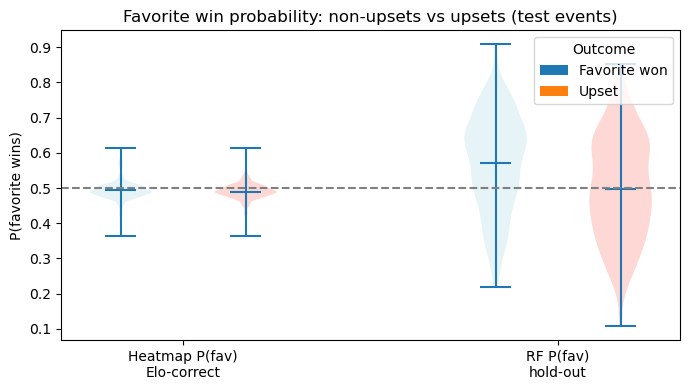

In [11]:
td['heatmap_p_fav'] = td.apply(heatmap_p_favorite_wins, axis=1)
td2 = td.dropna(subset=['heatmap_p_fav']).copy()

fig, ax = plt.subplots(figsize=(7, 4))
parts = ax.violinplot(
    [
        td2.loc[~td2['upset'], 'heatmap_p_fav'].values,
        td2.loc[td2['upset'], 'heatmap_p_fav'].values,
        td2.loc[~td2['upset'], 'p_fav_wins'].values,
        td2.loc[td2['upset'], 'p_fav_wins'].values,
    ],
    positions=[1, 2, 4, 5],
    showmeans=True,
)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(['Heatmap P(fav)\nElo-correct', 'RF P(fav)\nhold-out'])
ax.set_ylabel('P(favorite wins)')
from matplotlib.patches import Patch

ax.legend(
    handles=[Patch(facecolor='C0', label='Favorite won'), Patch(facecolor='C1', label='Upset')],
    title='Outcome',
)
# color violins: crude manual
for pc, c in zip(parts['bodies'], ['lightblue', 'salmon', 'lightblue', 'salmon']):
    pc.set_facecolor(c)
plt.title('Favorite win probability: non-upsets vs upsets (test events)')
plt.tight_layout()
plt.show()


### Takeaway (how to read this)
- **Heatmap:** Coarse **5×5** population rates. On upsets it will only look good if the **cluster pair** systematically favors the underdog; many upsets are driven by **individual** skill, age, or factors not in clusters, so alignment may stay near ~50%.
- **Random Forest:** Uses **richer** continuous Z-diffs but still **static** profiles (leakage). If `P(fav)` on upset fights is still **high**, the model is **confident in the wrong direction** often—typical for noisy fights.
- **Autoencoder model (notebook 12):** You can repeat this evaluation by swapping `feat_cols` for embedding diffs once you export embeddings to CSV; the **time-split** logic stays the same.
- **Better favorite definition:** Import **closing odds** when available; redo Elo labels with **proper event dates** from the raw scrape.

### Named upsets (Elo perspective)
Run after `fight_1` exists. **Interpretation:** Not closing odds—check whether the underdog win was an Elo-upset in *this* walk-through.


In [ ]:
# Requires earlier cells (fight_1)
pairs = [
    ('Michael Bisping', 'Luke Rockhold'),
    ('Julianna Pena', 'Amanda Nunes'),
    ('Sean Strickland', 'Israel Adesanya'),
]
if 'fight_1' not in dir():
    print("Run the Elo / fight_1 cells above first.")
else:
    for a, b in pairs:
        sub = fight_1[
            ((fight_1['Fighter']==a) & (fight_1['Opponent']==b))
            | ((fight_1['Fighter']==b) & (fight_1['Opponent']==a))
        ]
        if len(sub) == 0:
            print(f"No row: {a} vs {b}")
            continue
        r = sub.iloc[0]
        print(f"\n{r['Fighter']} vs {r['Opponent']} | Win for row fighter: {bool(r['Win_A'])}")



Michael Bisping vs Luke Rockhold | Win for row fighter: False

Amanda Nunes vs Julianna Pena | Win for row fighter: True

Sean Strickland vs Israel Adesanya | Win for row fighter: True
